In [ ]:
import numpy as np
import torch
import math

### Plotting

In [46]:
# now plot 3d graph of 1000 points sampled from the hemisphere
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def plot_sphere_points(points):
    # Plotting
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(points[:, 0], points[:, 1], points[:, 2], s=5, alpha=0.6)
    ax.view_init(elev=-45, azim=45)  # lower angle, looking diagonally


    ax.set_title("Sampled Points on a Hemisphere")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.set_box_aspect([1, 1, 1])
    # Optional: equal limits
    x_range = points[:, 0].max() - points[:, 0].min()
    y_range = points[:, 1].max() - points[:, 1].min()
    z_range = points[:, 2].max() - points[:, 2].min()
    max_range = max(x_range, y_range, z_range)

    x_center = (points[:, 0].max() + points[:, 0].min()) / 2
    y_center = (points[:, 1].max() + points[:, 1].min()) / 2
    z_center = (points[:, 2].max() + points[:, 2].min()) / 2

    ax.set_xlim(x_center - max_range/2, x_center + max_range/2)
    ax.set_ylim(y_center - max_range/2, y_center + max_range/2)
    ax.set_zlim(z_center - max_range/2, z_center + max_range/2)

    plt.tight_layout()
    plt.show()

# Sampling bias
Shows that the following linear sampling of theta linearly oversamples the location at the top of the hemisphere

In [38]:
def sample_hemisphere(
        radius_range=(0.2, 0.7),
        num_points=100,
        device="cpu"
    ):
        r = torch.empty(num_points, device=device).uniform_(radius_range[0], radius_range[1])
        phi = torch.empty(num_points, device=device).uniform_(0, math.pi * 2)  # azimuth
        theta = torch.empty(num_points, device=device).uniform_(0, math.pi / 2)

        x = r * torch.sin(theta) * torch.cos(phi)
        y = r * torch.sin(theta) * torch.sin(phi)
        z = r * torch.cos(theta)  # bias up to avoid below-table goals

        offset = torch.tensor([0.0, 0.0, 0.1], device=device)  # offset above table
        goal_pos = torch.stack((x, y, z), dim=1) + offset

        return goal_pos

### Corrected sampling techniques

In [41]:
# cosine correction
def sample_hemisphere_surface(num_points=1000, radius_range=(0.2, 0.7), device="cpu"):
    phi = torch.rand(num_points, device=device) * 2 * math.pi
    z = torch.rand(num_points, device=device)  # z ∈ [0, 1]
    radius = torch.empty(num_points, device=device).uniform_(radius_range[0], radius_range[1])
    theta = torch.acos(z)  # corrected inclination

    x = torch.sin(theta) * torch.cos(phi)
    y = torch.sin(theta) * torch.sin(phi)
    z = torch.cos(theta)

    points = torch.stack([x, y, z], dim=1) *  radius[:, None]
    return points

def sample_hemisphere_volume(num_points=1000, radius_range=(0.2, 0.7), device="cpu"):
    u = torch.rand(num_points, device=device)
    v = torch.rand(num_points, device=device)
    w = torch.rand(num_points, device=device)
    radius = torch.empty(num_points, device=device).uniform_(radius_range[0], radius_range[1])

    phi = 2 * math.pi * u
    costheta = 1 - v  # ensures z ≥ 0 hemisphere
    theta = torch.acos(costheta)
    r = radius * w ** (1/3)  # cube root to preserve uniform density

    x = r * torch.sin(theta) * torch.cos(phi)
    y = r * torch.sin(theta) * torch.sin(phi)
    z = r * torch.cos(theta)

    return torch.stack((x, y, z), dim=1)

In [44]:
# Sample points naive
naive_points = sample_hemisphere(num_points=10000, radius_range=(0.5, 0.7))
surface_points = sample_hemisphere_surface(num_points=10000, radius_range=(0.5, 0.7))
volume_points = sample_hemisphere_volume(num_points=10000, radius_range=(0.5, 0.7))


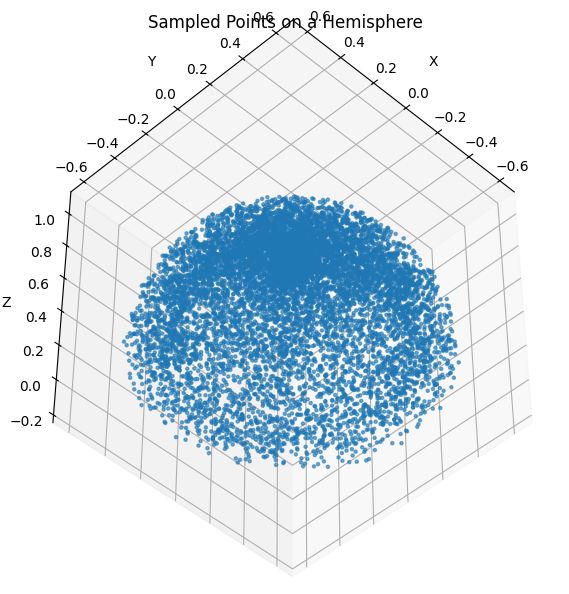

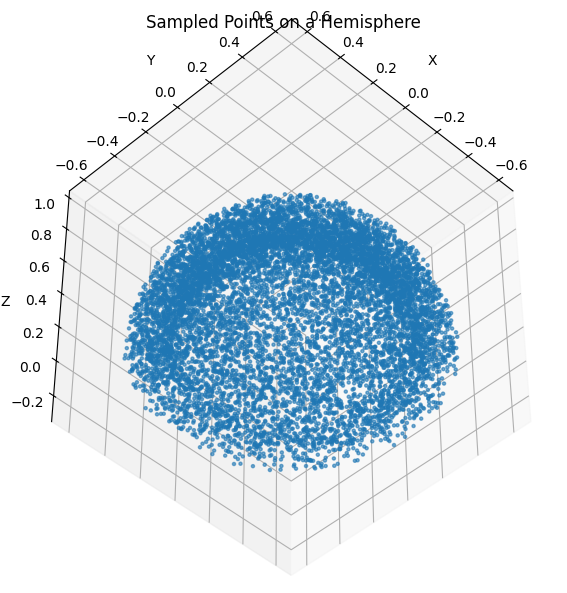

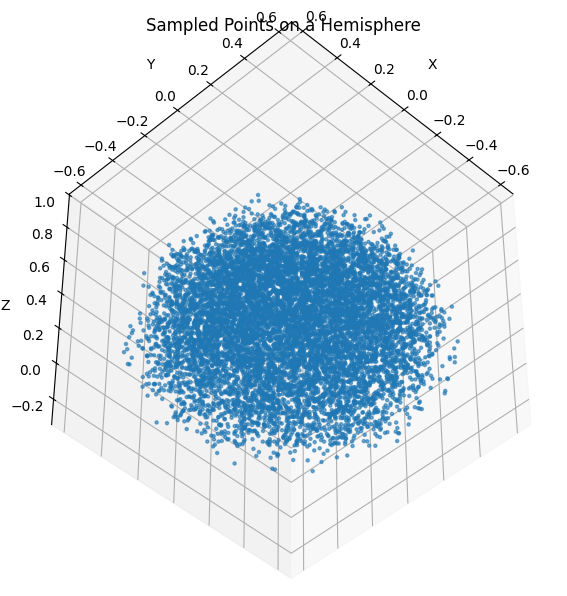

In [47]:
plot_sphere_points(naive_points)
plot_sphere_points(surface_points)
plot_sphere_points(volume_points)
